# Modelo con Transfer Learning (EfficientNetB7)

In [1]:
#Importamos librerías e importamos el modelo EfficientNetB7 que ya fue preentrenado

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import models, layers
from tensorflow.keras.applications import EfficientNetB7
from tensorflow.keras.callbacks import ModelCheckpoint

In [2]:
#Cargamos los datos de train, test y las etiquetas que se guardaron en etapas previas

train_img = np.load("train_img.npy")
test_img = np.load("test_img.npy")

train_labels = np.load("train_labels.npy")
test_labels = np.load("test_labels.npy")

class_names = np.load("class_names.npy", allow_pickle=True)

num_classes = len(class_names)


In [3]:
#Creamos la función de Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
])

In [4]:
#Imprimimos información sobre las clases y sus etiquetas para ver que todo este en orden
print("num_classes:", num_classes)
print("class_names:", class_names)
print("len(class_names):", len(class_names))
print("label mínimo:", train_labels.min())
print("label máximo:", train_labels.max())

num_classes: 18
class_names: ['Ace' 'Akainu' 'Brook' 'Chopper' 'Crocodile' 'Franky' 'Jinbei' 'Kurohige'
 'Law' 'Luffy' 'Mihawk' 'Nami' 'Rayleigh' 'Robin' 'Sanji' 'Shanks' 'Usopp'
 'Zoro']
len(class_names): 18
label mínimo: 0
label máximo: 17


In [5]:
#Definimos el modelo de Transfer Learning utilizando EfficientNetB7 como base.

def get_model_transfer_learning(input_shape, num_classes):
    #Cargamos el modelo EfficientMetB7 preentrenado
    base_model = EfficientNetB7(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    #Congelamos las capas del modelo para que no se vayan actualizando
    base_model.trainable = False

    #Agregamos capas para adaptar el modelo a clasificar 
    model = models.Sequential([
        layers.Input(shape=input_shape),

        data_augmentation,

        # Como el modelo espera una entrada de 224x244 tenemos que redimensionar las imágenes de entrada
        layers.Resizing(224, 224),

        #Rescalamos los valores a un rango de 0 a 1 para que el modelo lo pueda procesar mejor 
        layers.Rescaling(255.0),

        # Aqui es donde agregamos el modelo preentrenado EfficientNetB7
        base_model,

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4,),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation="softmax")
    ])

    return model


model_tl = get_model_transfer_learning(
    input_shape=(64, 64, 3),
    num_classes=num_classes
)

model_tl.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb7 (Functional)     │ (None, 7, 7, 2560)     │    64,097,687 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2560)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       655,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,789,545 (247.15 MB)

 Trainable params: 691,346 (2.64 MB)

 Non-trainable params: 64,098,199 (244.52 MB)

In [ ]:
#Compilamos el modelo 
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
#Hacemos un checkpoint para guardar el mejor modelo
checkpoint_tl = ModelCheckpoint(
    filepath="best_model_tl.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [8]:
#Definimos callbacks por si el modelo deja de mejorar en la etapa de train

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

early_stop_tl = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_tl = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [9]:
#Entrenamos el modelo
history_tl = model_tl.fit(
    train_img,
    train_labels,
    validation_split=0.2,
    epochs=30,
    batch_size=16,
    callbacks=[checkpoint_tl, early_stop_tl, reduce_lr_tl]
)

Epoch 1/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.1349 - loss: 3.2372
Epoch 1: val_accuracy improved from None to 0.39457, saving model to best_model_tl.keras

Epoch 1: finished saving model to best_model_tl.keras
470/470 ━━━━━━━━━━━━━━━━━━━━ 374s 780ms/step - accuracy: 0.1859 - loss: 2.9024 - val_accuracy: 0.3946 - val_loss: 1.9813 - learning_rate: 3.0000e-04
Epoch 2/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - accuracy: 0.2864 - loss: 2.3840
Epoch 2: val_accuracy improved from 0.39457 to 0.49255, saving model to best_model_tl.keras

Epoch 2: finished saving model to best_model_tl.keras
470/470 ━━━━━━━━━━━━━━━━━━━━ 361s 769ms/step - accuracy: 0.3002 - loss: 2.3451 - val_accuracy: 0.4925 - val_loss: 1.7055 - learning_rate: 3.0000e-04
Epoch 3/30
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.3513 - loss: 2.1385
Epoch 3: val_accuracy improved from 0.49255 to 0.53461, saving model to best_model_tl.keras

Epoch 3: finished saving model to best_model_tl.keras


# Métricas

In [11]:
#Cargamos el modelo guardado que tuvo el mejor accurcy durante la etapa de train

best_model_tl = tf.keras.models.load_model(
    "best_model_tl.keras"
)

#Hacemos predicciones con el modelo para ver como desempeña en el set de test

y_pred_probs = best_model_tl.predict(test_img)

y_pred_classes = np.argmax(
    y_pred_probs,
    axis=1
)

74/74 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step


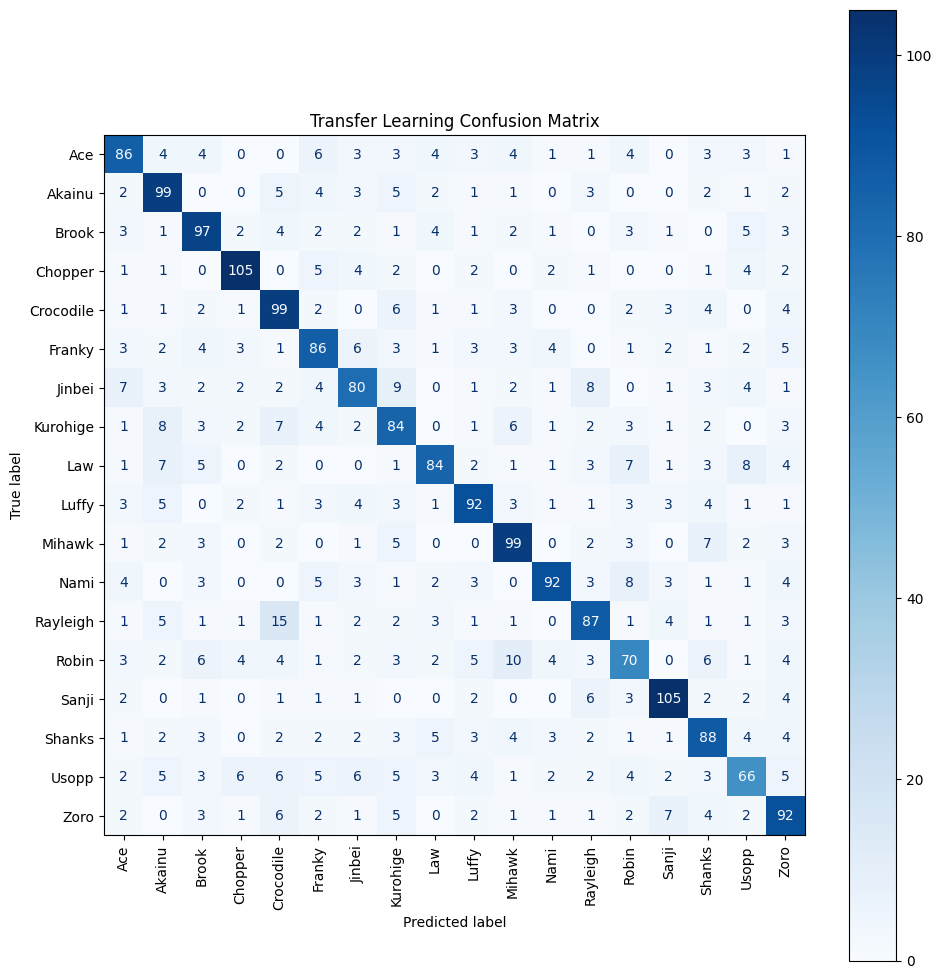

In [12]:
#Calculamos la matriz de confusión para comparar con los modelos anteriores

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    test_labels,
    y_pred_classes
)

fig, ax = plt.subplots(figsize=(10,10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90
)

plt.title("Transfer Learning Confusion Matrix")
plt.tight_layout()
plt.show()

In [13]:
#Calculamos las métricas de evaluación para comparar con los modelos anteriores

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    test_labels,
    y_pred_classes
)

precision = precision_score(
    test_labels,
    y_pred_classes,
    average="weighted"
)

recall = recall_score(
    test_labels,
    y_pred_classes,
    average="weighted"
)

f1 = f1_score(
    test_labels,
    y_pred_classes,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.6861158432708688
Precision: 0.6877656916351731
Recall   : 0.6861158432708688
F1 Score : 0.6852232139410329
